<h1>Импорт библиотек

In [3]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [ ]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    n = X[0].shape[0]
    result = np.zeros((n, 1), dtype=np.float64)
    for xi, vi in zip(X, V):
        result += xi @ vi
    return result

def tests():
    # одна матрица и один вектор
    X1 = [np.array([[1, 2], [3, 4]])]
    V1 = [np.array([[5], [6]])]
    res1 = sum_prod(X1, V1)
    expected1 = np.array([[1*5 + 2*6],
                          [3*5 + 4*6]])
    assert np.allclose(res1, expected1)

    # две матрицы и два вектора
    X2 = [
        np.array([[1, 0], [0, 1]]),
        np.array([[2, 1], [1, 2]])
    ]
    V2 = [
        np.array([[1], [1]]),
        np.array([[2], [3]])
    ]
    # X1*v1 = [1,1], X2*v2 = [2*2+1*3, 1*2+2*3] = [7, 8]
    # sum = [1+7, 1+8] = [8, 9]
    res2 = sum_prod(X2, V2)
    expected2 = np.array([[8], [9]])
    assert np.allclose(res2, expected2)

    # три матрицы и три вектора
    X3 = [
        np.array([[2, 3], [4, 5]]),
        np.array([[1, 1], [1, 1]]),
        np.array([[0, 1], [1, 0]])
    ]
    V3 = [
        np.array([[6], [7]]),
        np.array([[1], [2]]),
        np.array([[3], [4]])
    ]
    # X1*v1 = [2*6+3*7, 4*6+5*7] = [12+21, 24+35] = [33, 59]
    # X2*v2 = [1+2, 1+2] = [3, 3]
    # X3*v3 = [0*3+1*4, 1*3+0*4] = [4, 3]
    # sum = [33+3+4, 59+3+3] = [40, 65]
    res3 = sum_prod(X3, V3)
    expected3 = np.array([[40], [65]])
    assert np.allclose(res3, expected3)

    print("All tests passed!")


tests()

All tests passed!


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [ ]:
def binarize(M, threshold=0.5):
    return (M > threshold).astype(np.int8)

def tests():
    # бинаризация матрицы с порогом 0.5
    M1 = np.array([[0.1, 0.6], [0.4, 0.8]])
    res1 = binarize(M1, threshold=0.5)
    expected1 = np.array([[0, 1], [0, 1]])
    assert np.allclose(res1, expected1)

    # бинаризация матрицы с порогом 0.3
    M2 = np.array([[0.1, 0.6], [0.4, 0.8]])
    res2 = binarize(M2, threshold=0.3)
    expected2 = np.array([[0, 1], [1, 1]])
    assert np.allclose(res2, expected2)

    print("All tests passed!")

tests()


All tests passed!


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [12]:
def unique_rows(mat):
    return np.unique(mat, axis=0)

def unique_columns(mat):
    return np.unique(mat, axis=1)

def tests():
    # разные строки и столбцы
    M1 = np.array([
        [1, 2, 3],
        [1, 2, 3],
        [4, 5, 6],
        [1, 2, 3],
        [4, 5, 6]
    ])

    ur1 = unique_rows(M1)
    expected_rows1 = np.array([
        [1, 2, 3],
        [4, 5, 6]
    ])
    assert ur1.shape == expected_rows1.shape
    assert np.array_equal(ur1, expected_rows1)

    uc1 = unique_columns(M1)
    assert uc1.shape == (5, 3)

    # повторяющиеся столбцы
    M2 = np.array([
        [1, 2, 1],
        [3, 4, 3],
        [5, 6, 5]
    ])
    uc2 = unique_columns(M2)
    assert uc2.shape == (3, 2)

    # все строки одинаковые
    M3 = np.array([
        [7, 8, 9],
        [7, 8, 9],
        [7, 8, 9]
    ])
    ur3 = unique_rows(M3)
    assert ur3.shape == (1, 3)
    assert np.array_equal(ur3, np.array([[7, 8, 9]]))

    # пустая матрица (0 строк или 0 столбцов)
    M4 = np.array([]).reshape(0, 3)
    ur4 = unique_rows(M4)
    assert ur4.shape == (0, 3)

    M5 = np.array([]).reshape(3, 0)
    uc5 = unique_columns(M5)
    assert uc5.shape == (3, 0)

    print("All tests passed!")


tests()

All tests passed!


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

Stats tests passed!


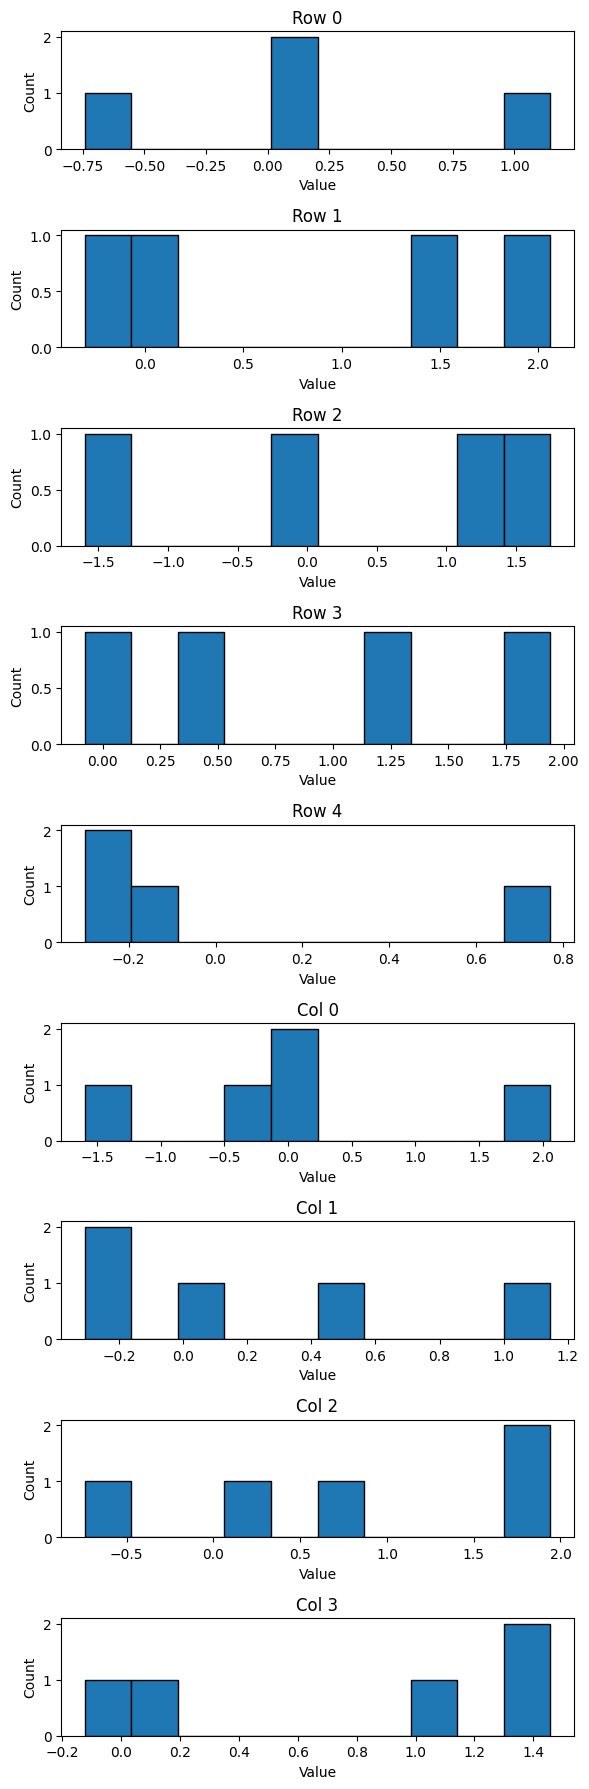

Plot test passed (check output visually)!


In [ ]:
def create_mat_norm(m, n):
    mat = np.random.normal(loc=0, scale=1, size=(m, n))
    return mat

def stats_rows_cols(mat: np.ndarray):
    mean_rows = mat.mean(axis=1)
    var_rows = mat.var(axis=1)

    mean_cols = mat.mean(axis=0)
    var_cols = mat.var(axis=0)

    return mean_rows, var_rows, mean_cols, var_cols

def plot_histograms_rows_cols(mat: np.ndarray, bins=20):
    """
    Строит гистограммы:
      - для каждой строки матрицы (вверху)
      - для каждого столбца матрицы (внизу)
    Использует subplot.
    """
    m, n = mat.shape

    # количество подграфиков: m строк + n столбцов
    total = m + n
    _, axes = plt.subplots(total, 1, figsize=(6, 2 * total), squeeze=False)
    axes = axes[:, 0]

    # гистограммы строк
    for i in range(m):
        row_data = mat[i, :]
        axes[i].hist(row_data, bins=bins, edgecolor='black')
        axes[i].set_title(f'Row {i}')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')

    # гистограммы столбцов
    for j in range(n):
        col_data = mat[:, j]
        idx = m + j
        axes[idx].hist(col_data, bins=bins, edgecolor='black')
        axes[idx].set_title(f'Col {j}')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

def tests():
    m, n = 5, 4
    mat = create_mat_norm(m, n)

    assert mat.shape == (m, n)
    assert isinstance(mat, np.ndarray)

    mean_rows, var_rows, mean_cols, var_cols = stats_rows_cols(mat)

    assert mean_rows.shape == (m,)
    assert var_rows.shape == (m,)
    assert mean_cols.shape == (n,)
    assert var_cols.shape == (n,)

    # дисперсия >= 0
    assert all(var_rows >= 0)
    assert all(var_cols >= 0)

    print("Stats tests passed!")

    # Тест гистограмм
    plot_histograms_rows_cols(mat, bins=10)
    print("Plot test passed!")


tests()

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [15]:
def chess_matrix(m, n, a, b):
    base = np.array([[a, b],
                     [b, a]])
    # tile повторяет base нужное количество раз
    full = np.tile(base, ( (m + 1) // 2, (n + 1) // 2 ))
    return full[:m, :n]

def tests():
    # базовый случай
    M1 = chess_matrix(4, 4, 1, 0)
    expected1 = np.array([
        [1, 0, 1, 0],
        [0, 1, 0, 1],
        [1, 0, 1, 0],
        [0, 1, 0, 1]
    ], dtype=np.int64)
    assert np.array_equal(M1, expected1)

    # нечётные размеры
    M2 = chess_matrix(3, 5, 2, 3)
    expected2 = np.array([
        [2, 3, 2, 3, 2],
        [3, 2, 3, 2, 3],
        [2, 3, 2, 3, 2]
    ], dtype=np.int64)
    assert np.array_equal(M2, expected2)

    # одна строка
    M3 = chess_matrix(1, 6, 5, 7)
    expected3 = np.array([[5, 7, 5, 7, 5, 7]], dtype=np.int64)
    assert np.array_equal(M3, expected3)

    # один столбец
    M4 = chess_matrix(5, 1, 5, 7)
    expected4 = np.array([
        [5],
        [7],
        [5],
        [7],
        [5]
    ], dtype=np.int64)
    assert np.array_equal(M4, expected4)

    print("All tests passed!")


tests()

All tests passed!


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

All tests passed!


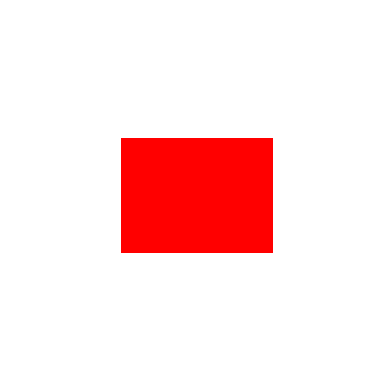

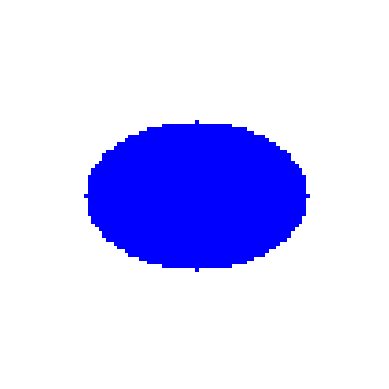

In [ ]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    # Создаём изображение с фоном
    img = np.zeros((m, n, 3), dtype=np.uint8)
    img[:, :, 0] = background_color[0]
    img[:, :, 1] = background_color[1]
    img[:, :, 2] = background_color[2]

    R, G, B = rectangle_color

    # Центр прямоугольника
    x0, y0 = n / 2.0, m / 2.0

    # Границы
    x_min = int(x0 - a / 2)
    x_max = int(x0 + a / 2)
    y_min = int(y0 - b / 2)
    y_max = int(y0 + b / 2)

    # Ограничиваем рамками изображения
    x_min = max(0, x_min)
    x_max = min(n - 1, x_max)
    y_min = max(0, y_min)
    y_max = min(m - 1, y_max)

    # Красим прямоугольник через срез
    img[y_min:y_max + 1, x_min:x_max + 1, 0] = R
    img[y_min:y_max + 1, x_min:x_max + 1, 1] = G
    img[y_min:y_max + 1, x_min:x_max + 1, 2] = B

    return img


def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    img = np.zeros((m, n, 3), dtype=np.uint8)
    img[:, :, 0] = background_color[0]
    img[:, :, 1] = background_color[1]
    img[:, :, 2] = background_color[2]

    R, G, B = ellipse_color

    x0, y0 = n / 2.0, m / 2.0

    x = np.arange(n)
    y = np.arange(m)

    # 2D-поля координат
    X = x[np.newaxis, :] 
    Y = y[:, np.newaxis]

    mask = ((X - x0) ** 2) / (a ** 2) + ((Y - y0) ** 2) / (b ** 2) <= 1.0

    img[mask, 0] = R
    img[mask, 1] = G
    img[mask, 2] = B

    return img



def show_image(img):
    plt.imshow(img)
    plt.axis('off')
    plt.show()

def tests():
    m, n = 100, 100
    bg_color = (255, 255, 255)
    rect_color = (255, 0, 0)
    oval_color = (0, 0, 255)

    # прямоугольник
    img_rect = draw_rectangle(40, 30, m, n, rect_color, bg_color)
    assert img_rect.shape == (m, n, 3)
    # центр прямоугольника должен быть красным
    cx, cy = n // 2, m // 2
    assert img_rect[cy, cx, 0] == 255 and img_rect[cy, cx, 1] == 0 and img_rect[cy, cx, 2] == 0
    # край изображения - фон
    assert img_rect[0, 0, 0] == 255 and img_rect[0, 0, 1] == 255 and img_rect[0, 0, 2] == 255

    # эллипс
    img_oval = draw_ellipse(30, 20, m, n, oval_color, bg_color)
    assert img_oval.shape == (m, n, 3)
    # центр эллипса - синий
    assert img_oval[cy, cx, 0] == 0 and img_oval[cy, cx, 1] == 0 and img_oval[cy, cx, 2] == 255
    # край - фон
    assert img_oval[0, 0, 0] == 255 and img_oval[0, 0, 1] == 255 and img_oval[0, 0, 2] == 255

    print("All tests passed!")

    show_image(img_rect)
    show_image(img_oval)


tests()

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

Mean: 0.0281, Variance: 0.6035, Std: 0.7769
Maxima: 16, Minima: 17
All tests passed!


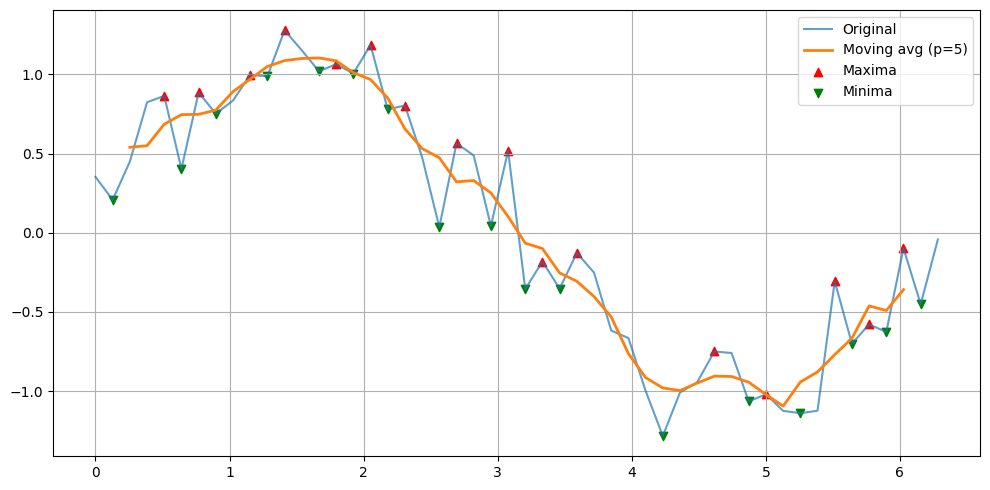

In [25]:
def compute_statistics(series):
    """Возвращает (среднее, дисперсия, СКО)."""
    return np.mean(series), np.var(series), np.std(series)

def find_local_extrema(series):
    """Возвращает индексы локальных максимумов и минимумов."""
    s = series
    max_mask = (s[1:-1] > s[:-2]) & (s[1:-1] > s[2:])
    min_mask = (s[1:-1] < s[:-2]) & (s[1:-1] < s[2:])
    return np.where(max_mask)[0] + 1, np.where(min_mask)[0] + 1

def moving_average(series, p):
    """Центрированное скользящее среднее с окном p. Возвращает (x-индексы, значения)."""
    kernel = np.ones(p) / p
    ma = np.convolve(series, kernel, mode='valid')
    offset = (p - 1) // 2
    return np.arange(offset, offset + len(ma)), ma

def plot_series(t, series, p, ma_x, ma, max_idx, min_idx):
    """Визуализация ряда, скользящего среднего и экстремумов."""
    plt.figure(figsize=(10, 5))
    plt.plot(t, series, alpha=0.7, label='Original')
    plt.plot(t[ma_x], ma, linewidth=2, label=f'Moving avg (p={p})')
    plt.scatter(t[max_idx], series[max_idx], c='red', marker='^', label='Maxima')
    plt.scatter(t[min_idx], series[min_idx], c='green', marker='v', label='Minima')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Тестовый ряд
    np.random.seed(0)
    t = np.linspace(0, 2 * np.pi, 50)
    series = np.sin(t) + 0.2 * np.random.randn(len(t))
    p = 5

    mean, var, std = compute_statistics(series)
    print(f"Mean: {mean:.4f}, Variance: {var:.4f}, Std: {std:.4f}")

    max_idx, min_idx = find_local_extrema(series)
    print(f"Maxima: {len(max_idx)}, Minima: {len(min_idx)}")

    ma_x, ma = moving_average(series, p)

    # Проверки
    assert abs(mean) < 0.5, "Среднее должно быть около 0"
    assert var > 0, "Дисперсия положительна"
    assert len(max_idx) > 0, "Ожидается хотя бы один максимум"
    assert len(ma) == len(series) - p + 1, "Неверная длина скользящего среднего"

    print("All tests passed!")
    plot_series(t, series, p, ma_x, ma, max_idx, min_idx)

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [26]:
def one_hot_encode(labels, num_classes=None):
    """Возвращает one-hot матрицу для вектора целочисленных меток."""
    labels = np.asarray(labels, dtype=int)
    if num_classes is None:
        num_classes = labels.max() + 1
    oh = np.zeros((len(labels), num_classes), dtype=int)
    oh[np.arange(len(labels)), labels] = 1
    return oh

if __name__ == '__main__':
    vec = [0, 2, 3, 0]
    oh = one_hot_encode(vec)
    print("One-hot encoded:\n", oh)

    # Проверки
    assert oh.shape == (4, 4), "Неверная форма"
    assert np.all(np.sum(oh, axis=1) == 1), "Сумма по строке должна быть 1"
    assert np.array_equal(oh[0], [1, 0, 0, 0]), "Ошибка в первой строке"
    assert np.array_equal(oh[1], [0, 0, 1, 0]), "Ошибка во второй строке"
    assert np.array_equal(oh[2], [0, 0, 0, 1]), "Ошибка в третьей строке"
    assert np.array_equal(oh[3], [1, 0, 0, 0]), "Ошибка в четвёртой строке"
    print("All tests passed!")

One-hot encoded:
 [[1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]
All tests passed!
